## PRT564 — Data Analytics & Visualisation
### Model Evaluation & Discussion

In [1]:
import os

BASE = r"C:\Users\ranas\OneDrive\Desktop\Rana_Research_Workspace\Rana_Research_Workspace"
REG_OUT  = os.path.join(BASE, "Regression_Outputs")
EVAL_OUT = os.path.join(BASE, "Evaluation_Outputs")
os.makedirs(EVAL_OUT, exist_ok=True)

for p, n in [(REG_OUT,"Regression_Outputs"),(EVAL_OUT,"Evaluation_Outputs")]:
    print(n, "found" if os.path.exists(p) else "NOT FOUND")

Regression_Outputs found
Evaluation_Outputs found


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel, wilcoxon, shapiro
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)

In [3]:
results_df = pd.read_csv(os.path.join(REG_OUT, 'model_results.csv'))
preds_df   = pd.read_csv(os.path.join(REG_OUT, 'model_predictions.csv'), parse_dates=['quarter'])

print(results_df.to_string(index=False))

actual      = preds_df['actual'].values
pred_ols    = preds_df['pred_ols'].values
pred_ridge  = preds_df['pred_ridge'].values
pred_lasso  = preds_df['pred_lasso'].values
resid_ols   = preds_df['resid_ols'].values
resid_ridge = preds_df['resid_ridge'].values
resid_lasso = preds_df['resid_lasso'].values

Model  Train_MAE  Train_RMSE  Train_R2  Test_MAE  Test_RMSE  Test_R2  CV_Mean_R2  CV_Std_R2
  OLS   0.035324    0.042791  0.999997  0.242260   0.413582 0.999203    0.999470   0.000429
Ridge   0.062370    0.075598  0.999989  0.316420   0.472504 0.998959    0.995975   0.004470
Lasso   0.043873    0.052059  0.999995  0.241895   0.402406 0.999245    0.999326   0.000932


In [4]:
# MAE — robust to outliers, good for plain-language communication
# RMSE — penalises large errors more, reflects COVID-era extremes
# R²   — scale-free explanatory power, comparable across models

print(f"{'Metric':<25} {'OLS':>10} {'Ridge':>10} {'Lasso':>10}")
print("-"*57)
metrics = [
    ('Test MAE',          mean_absolute_error(actual, pred_ols),
                          mean_absolute_error(actual, pred_ridge),
                          mean_absolute_error(actual, pred_lasso)),
    ('Test RMSE',         np.sqrt(mean_squared_error(actual, pred_ols)),
                          np.sqrt(mean_squared_error(actual, pred_ridge)),
                          np.sqrt(mean_squared_error(actual, pred_lasso))),
    ('Test R²',           r2_score(actual, pred_ols),
                          r2_score(actual, pred_ridge),
                          r2_score(actual, pred_lasso)),
    ('Max Abs Error',     np.max(np.abs(resid_ols)),
                          np.max(np.abs(resid_ridge)),
                          np.max(np.abs(resid_lasso))),
    ('Mean Residual',     np.mean(resid_ols),
                          np.mean(resid_ridge),
                          np.mean(resid_lasso)),
]
for label, o, r, l in metrics:
    print(f"  {label:<23} {o:>10.4f} {r:>10.4f} {l:>10.4f}")

Metric                           OLS      Ridge      Lasso
---------------------------------------------------------
  Test MAE                    0.2423     0.3164     0.2419
  Test RMSE                   0.4136     0.4725     0.4024
  Test R²                     0.9992     0.9990     0.9992
  Max Abs Error               1.0310     1.1688     1.0332
  Mean Residual              -0.2113    -0.3033    -0.2212


In [5]:
ae_ols   = np.abs(resid_ols)
ae_ridge = np.abs(resid_ridge)
ae_lasso = np.abs(resid_lasso)

# step 1: check if differences are normal before choosing test
sw1, p_sw1 = shapiro(ae_ols - ae_lasso)
sw2, p_sw2 = shapiro(ae_ols - ae_ridge)
print(f"Shapiro-Wilk OLS vs Lasso: p={p_sw1:.4f} ({'normal' if p_sw1>0.05 else 'not normal'})")
print(f"Shapiro-Wilk OLS vs Ridge: p={p_sw2:.4f} ({'normal' if p_sw2>0.05 else 'not normal'})")

# H0: no difference in mean absolute error between models
# alpha = 0.05

t, p_t = ttest_rel(ae_ols, ae_lasso)
print(f"\nt-test OLS vs Lasso: t={t:.4f}, p={p_t:.4f}")
print("FAIL TO REJECT H0" if p_t >= 0.05 else "REJECT H0")

w1, p_w1 = wilcoxon(ae_ols, ae_ridge)
print(f"\nWilcoxon OLS vs Ridge: W={w1:.0f}, p={p_w1:.4f}")
print("FAIL TO REJECT H0" if p_w1 >= 0.05 else "REJECT H0 — OLS significantly better than Ridge")

w2, p_w2 = wilcoxon(ae_lasso, ae_ridge)
print(f"\nWilcoxon Lasso vs Ridge: W={w2:.0f}, p={p_w2:.4f}")
print("FAIL TO REJECT H0" if p_w2 >= 0.05 else "REJECT H0 — Lasso significantly better than Ridge")

Shapiro-Wilk OLS vs Lasso: p=0.2252 (normal)
Shapiro-Wilk OLS vs Ridge: p=0.4906 (normal)

t-test OLS vs Lasso: t=0.0237, p=0.9814
FAIL TO REJECT H0

Wilcoxon OLS vs Ridge: W=19, p=0.0353
REJECT H0 — OLS significantly better than Ridge

Wilcoxon Lasso vs Ridge: W=6, p=0.0017
REJECT H0 — Lasso significantly better than Ridge


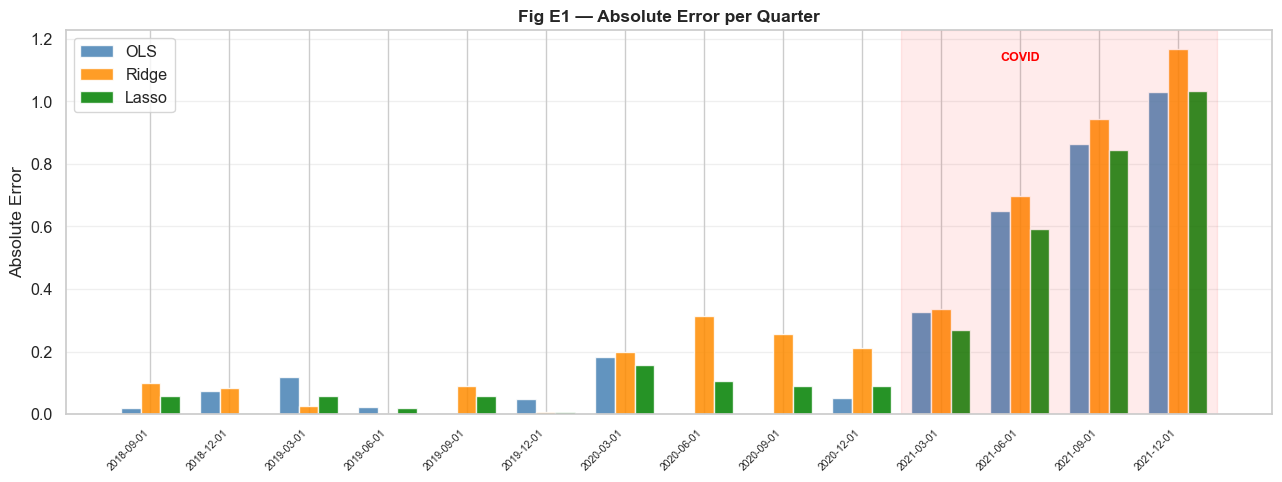

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
qts = preds_df['quarter'].tolist()
x = np.arange(len(qts))
w = 0.25

ax.bar(x-w, ae_ols,   w, label='OLS',   color='steelblue',  alpha=0.85, edgecolor='white')
ax.bar(x,   ae_ridge, w, label='Ridge', color='darkorange', alpha=0.85, edgecolor='white')
ax.bar(x+w, ae_lasso, w, label='Lasso', color='green',      alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([str(q.date()) for q in qts], rotation=45, ha='right', fontsize=7.5)
ax.axvspan(9.5, 13.5, alpha=0.08, color='red')
ax.text(11, ax.get_ylim()[1]*0.92, 'COVID', ha='center', fontsize=9, color='red', fontweight='bold')
ax.set_ylabel('Absolute Error'); ax.legend(); ax.grid(alpha=0.3, axis='y')
ax.set_title('Fig E1 — Absolute Error per Quarter', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUT, 'figE1_abs_error.png'), dpi=150, bbox_inches='tight')
plt.show()

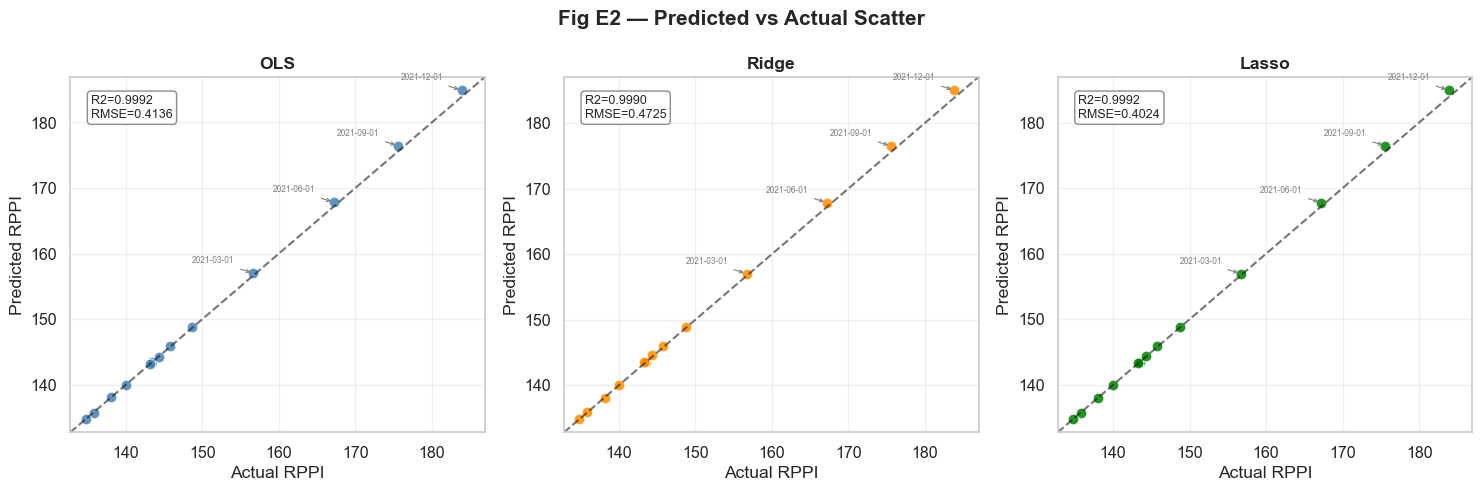

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, pred, color) in zip(axes,
    [('OLS', pred_ols, 'steelblue'),
     ('Ridge', pred_ridge, 'darkorange'),
     ('Lasso', pred_lasso, 'green')]):

    mn = min(actual.min(), pred.min()) - 2
    mx = max(actual.max(), pred.max()) + 2

    ax.scatter(actual, pred, color=color, s=60, alpha=0.85,
               edgecolors='white', lw=0.8)
    ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, alpha=0.6)

    for j in range(len(actual)):
        if actual[j] > 155:
            ax.annotate(str(preds_df['quarter'].iloc[j].date()),
                        xy=(actual[j], pred[j]),
                        xytext=(actual[j]-8, pred[j]+1.5),
                        fontsize=6, color='grey',
                        arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

    r2   = r2_score(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))

    ax.text(0.05, 0.95, f'R2={r2:.4f}\nRMSE={rmse:.4f}',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round', facecolor='white',
                      edgecolor='grey', alpha=0.9))

    ax.set_title(f'{name}', fontweight='bold')
    ax.set_xlabel('Actual RPPI')
    ax.set_ylabel('Predicted RPPI')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.grid(alpha=0.3)

fig.suptitle('Fig E2 — Predicted vs Actual Scatter', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUT, 'figE2_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

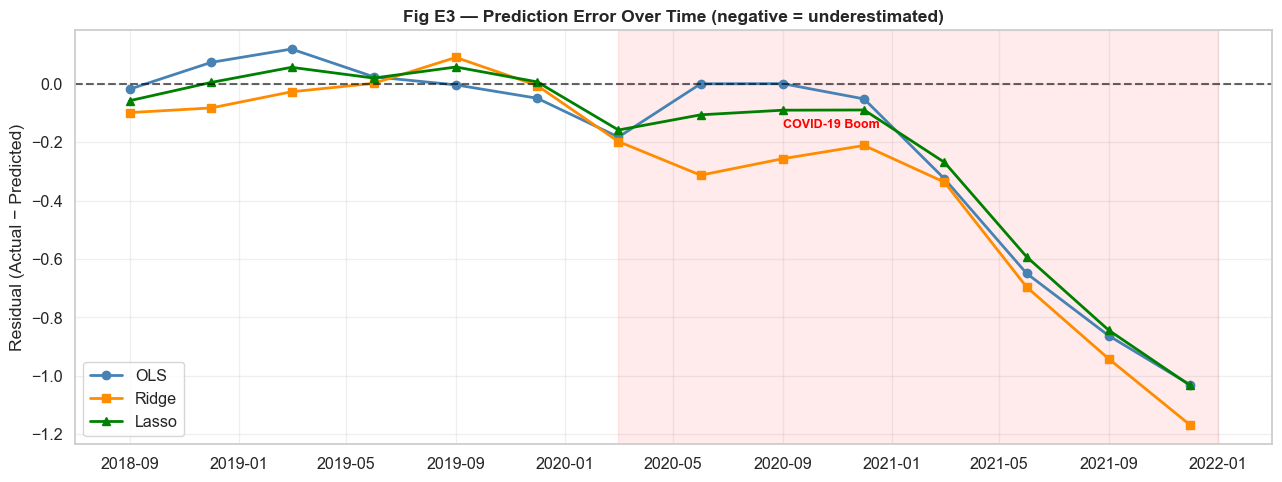

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(preds_df['quarter'], resid_ols,   color='steelblue',  lw=2, marker='o', ms=6, label='OLS')
ax.plot(preds_df['quarter'], resid_ridge, color='darkorange', lw=2, marker='s', ms=6, label='Ridge')
ax.plot(preds_df['quarter'], resid_lasso, color='green',      lw=2, marker='^', ms=6, label='Lasso')
ax.axhline(0, color='black', lw=1.5, ls='--', alpha=0.6)
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2022-01-01'), alpha=0.08, color='red')
ax.text(pd.Timestamp('2020-09-01'), -0.15, 'COVID-19 Boom', fontsize=9, color='red', fontweight='bold')
ax.set_title('Fig E3 — Prediction Error Over Time (negative = underestimated)', fontweight='bold')
ax.set_ylabel('Residual (Actual − Predicted)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(EVAL_OUT, 'figE3_error_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
summary = pd.DataFrame({
    'Test': ['Shapiro-Wilk (OLS vs Lasso diffs)','Shapiro-Wilk (OLS vs Ridge diffs)',
             'Paired t-test (OLS vs Lasso)','Wilcoxon (OLS vs Ridge)','Wilcoxon (Lasso vs Ridge)'],
    'Statistic': [sw1, sw2, t, w1, w2],
    'p_value':   [p_sw1, p_sw2, p_t, p_w1, p_w2],
    'Decision':  ['Normal — t-test valid','Normal — t-test valid',
                  'FAIL H0 — no significant difference',
                  'REJECT H0 — OLS better than Ridge (p<0.05)',
                  'REJECT H0 — Lasso better than Ridge (p<0.01)']
})
summary.to_csv(os.path.join(EVAL_OUT, 'statistical_tests.csv'), index=False)
print(summary.to_string(index=False))
print("\nall evaluation outputs saved")

                             Test  Statistic  p_value                                     Decision
Shapiro-Wilk (OLS vs Lasso diffs)   0.920715 0.225161                        Normal — t-test valid
Shapiro-Wilk (OLS vs Ridge diffs)   0.945315 0.490601                        Normal — t-test valid
     Paired t-test (OLS vs Lasso)   0.023707 0.981446          FAIL H0 — no significant difference
          Wilcoxon (OLS vs Ridge)  19.000000 0.035278   REJECT H0 — OLS better than Ridge (p<0.05)
        Wilcoxon (Lasso vs Ridge)   6.000000 0.001709 REJECT H0 — Lasso better than Ridge (p<0.01)

all evaluation outputs saved
